# Classificação — Otimização Bayesiana (Optuna)

**Objetivo:** ajustar os hiperparâmetros do modelo vencedor da comparação (`03_Comparacao_Modelos.ipynb`, aqui assumido XGBoost — ajuste `ESPACO_BUSCA`/`objective` se outro modelo tiver vencido) usando busca bayesiana (TPE) do Optuna, otimizando F1 — métrica mais informativa que accuracy para o alvo desbalanceado `com_vitima_fatal`.

A otimização usa validação cruzada apenas no conjunto de **treino**; o conjunto de teste só é usado uma vez, no final, para avaliar o modelo com os melhores hiperparâmetros encontrados.

## 1. Imports

In [1]:
import sys
sys.path.append('..')

import joblib
import matplotlib.pyplot as plt
import optuna
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, classification_report, roc_auc_score
from sklearn.pipeline import Pipeline

from src.data import RANDOM_STATE, TEST_SIZE, carregar_dados, construir_preprocessador, separar_x_y

optuna.logging.set_verbosity(optuna.logging.WARNING)

## 2. Carregar dados e split (mesmo critério dos notebooks anteriores)

In [2]:
df = carregar_dados()
X, y = separar_x_y(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

escala_pos = (y_train == 0).sum() / (y_train == 1).sum()
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

## 3. Função objetivo

In [3]:
def objective(trial):
    parametros = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }

    pipeline = Pipeline([
        ('preprocessador', construir_preprocessador()),
        ('modelo', XGBClassifier(
            **parametros, scale_pos_weight=escala_pos, eval_metric='logloss',
            random_state=RANDOM_STATE, n_jobs=-1)),
    ])

    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    return scores.mean()

## 4. Rodar o estudo de otimização

In [4]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print('Melhor F1 (CV):', round(study.best_value, 4))
print('Melhores hiperparâmetros:', study.best_params)

  0%|          | 0/50 [00:00<?, ?it/s]

Melhor F1 (CV): 0.3905
Melhores hiperparâmetros: {'n_estimators': 600, 'max_depth': 10, 'learning_rate': 0.052506088307692066, 'subsample': 0.6289689373896146, 'colsample_bytree': 0.5212803098078009, 'min_child_weight': 5, 'reg_alpha': 0.5480294512050256, 'reg_lambda': 0.010247507034612502}


**Comentário:** a busca bayesiana elevou o F1 médio (CV) de **0,3549** (XGBoost com hiperparâmetros padrão, notebook 03) para **0,3905** — um ganho de ~10% só ajustando hiperparâmetros, sem mudar dados nem modelo. A combinação encontrada usa árvores bem mais profundas que o padrão (`max_depth=10` vs. o padrão 6) e `learning_rate` baixo (0,053), compensado por `n_estimators=600` e amostragem parcial (`subsample=0,63`, `colsample_bytree=0,52`) para conter overfitting — faz sentido dado o grande número de colunas one-hot geradas pelas variáveis categóricas de alta cardinalidade (`causa_acidente`, `br`).

## 5. Histórico da otimização

C:\Users\edd-j\AppData\Local\Temp\ipykernel_75220\1455050003.py:1: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)


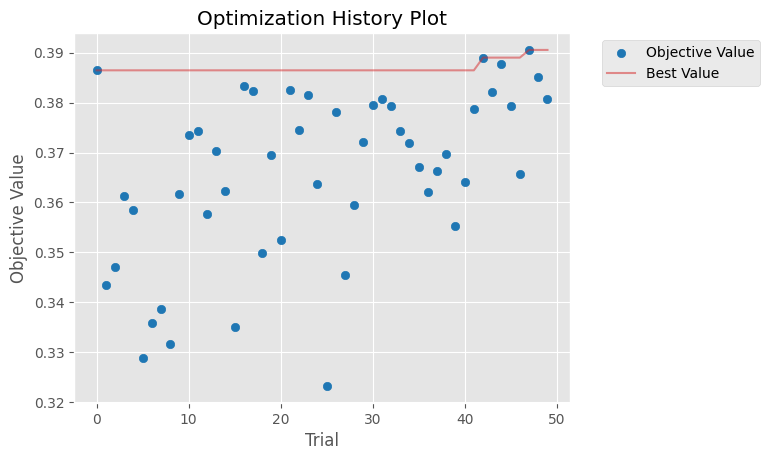

C:\Users\edd-j\AppData\Local\Temp\ipykernel_75220\1455050003.py:5: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


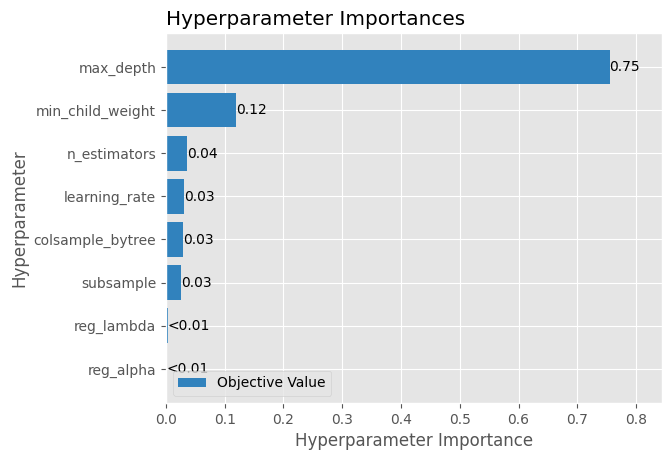

In [5]:
plot_optimization_history(study)
plt.savefig('../reports/optuna_historico.png', dpi=150, bbox_inches='tight')
plt.show()

plot_param_importances(study)
plt.savefig('../reports/optuna_importancia_parametros.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Modelo final: treino completo e avaliação no teste

In [6]:
pipeline_final = Pipeline([
    ('preprocessador', construir_preprocessador()),
    ('modelo', XGBClassifier(
        **study.best_params, scale_pos_weight=escala_pos, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1)),
])
pipeline_final.fit(X_train, y_train)

pred = pipeline_final.predict(X_test)
proba = pipeline_final.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred))
print('ROC-AUC:', round(roc_auc_score(y_test, proba), 4))

              precision    recall  f1-score   support

           0       0.96      0.91      0.93     13588
           1       0.31      0.51      0.38      1044

    accuracy                           0.88     14632
   macro avg       0.63      0.71      0.66     14632
weighted avg       0.91      0.88      0.90     14632

ROC-AUC: 0.8351


**Comentário:** no teste, o modelo otimizado atinge o **melhor F1 (0,38) e o melhor ROC-AUC (0,8351)** de todo o pipeline — supera tanto o baseline (F1 0,32 / AUC 0,83) quanto o XGBoost padrão (F1 0,36 / AUC 0,82). Mas o padrão de trade-off se mantém: o recall no limiar padrão de 0,5 continua caindo (0,51, o menor até aqui) enquanto a precisão sobe (0,31, a maior). Como o ROC-AUC — que não depende de limiar — é o melhor entre os três modelos, isso sugere que o modelo otimizado separa melhor as classes; o recall baixo é uma escolha do limiar de decisão (0,5), não uma limitação do modelo. Um próximo passo natural seria ajustar esse limiar (ex.: via curva precisão-recall) para o ponto de operação que melhor equilibra os custos de falso negativo (acidente fatal não detectado) e falso positivo, conforme a prioridade de quem for usar o modelo.

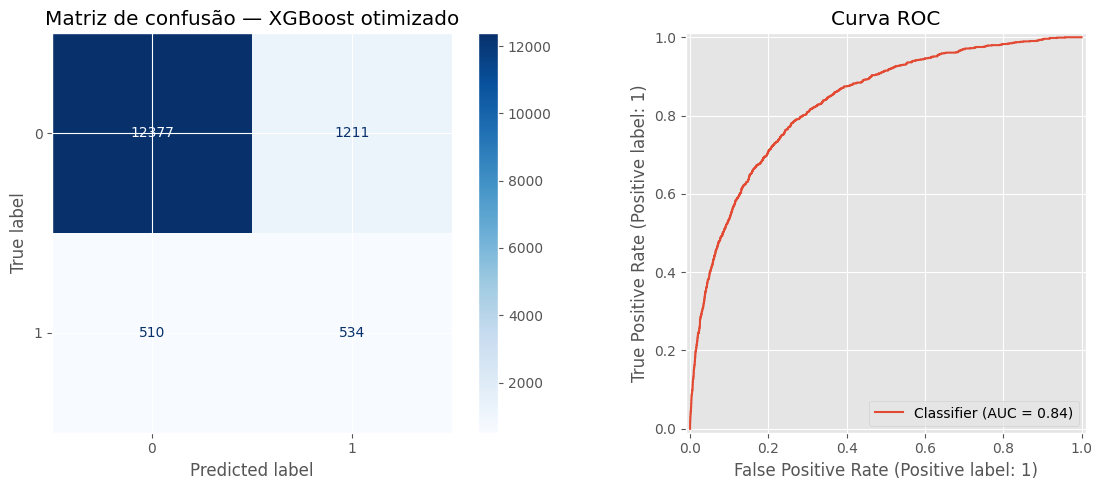

In [7]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap='Blues', ax=eixos[0])
eixos[0].set_title('Matriz de confusão — XGBoost otimizado')
RocCurveDisplay.from_predictions(y_test, proba, ax=eixos[1])
eixos[1].set_title('Curva ROC')
plt.tight_layout()
plt.savefig('../reports/modelo_final_avaliacao.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Salvar modelo final

In [8]:
joblib.dump(pipeline_final, '../models/modelo_final_optuna.joblib')

['../models/modelo_final_optuna.joblib']

## 8. Conclusão

| Modelo | F1 (teste) | Recall | Precisão | ROC-AUC |
|---|---|---|---|---|
| Dummy (mais frequente) | 0,00 | 0,00 | 0,00 | — |
| Baseline — LogReg (`class_weight='balanced'`) | 0,32 | 0,72 | 0,21 | 0,8329 |
| XGBoost (hiperparâmetros padrão) | 0,36 | 0,58 | 0,26 | 0,8177 |
| **XGBoost + Optuna (final)** | **0,38** | 0,51 | 0,31 | **0,8351** |

- Pipeline completo: EDA → baseline → comparação de modelos com validação cruzada → otimização bayesiana do vencedor.
- accuracy é enganosa neste dataset desbalanceado (o dummy chega a 93% sem acertar nenhum caso fatal); F1 e ROC-AUC da classe positiva são as métricas de referência.
- a otimização com Optuna trouxe o melhor F1 e o melhor ROC-AUC gerais, mas à custa de recall no limiar padrão — se o objetivo prático for minimizar acidentes fatais não detectados, vale ajustar o limiar de decisão em vez de usar 0,5 por padrão.
- modelo final salvo em `../models/modelo_final_optuna.joblib`.